In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("dataset/cleaned_5250.csv")

# Verificando se o DF foi importado com sucesso:
df.head(10)


,name,distance,stellar_magnitude,planet_type,discovery_year,mass_multiplier,mass_wrt,radius_multiplier,radius_wrt,orbital_radius,orbital_period,eccentricity,detection_method
0,11 Comae Berenices b,304.0,4.72307,Gas Giant,2007,19.40000,Jupiter,1.080,Jupiter,1.290000,0.892539,0.23,Radial Velocity
1,11 Ursae Minoris b,409.0,5.01300,Gas Giant,2009,14.74000,Jupiter,1.090,Jupiter,1.530000,1.400000,0.08,Radial Velocity
2,14 Andromedae b,246.0,5.23133,Gas Giant,2008,4.80000,Jupiter,1.150,Jupiter,0.830000,0.508693,0.00,Radial Velocity
3,14 Herculis b,58.0,6.61935,Gas Giant,2002,8.13881,Jupiter,1.120,Jupiter,2.773069,4.800000,0.37,Radial Velocity
4,16 Cygni B b,69.0,6.21500,Gas Giant,1996,1.78000,Jupiter,1.200,Jupiter,1.660000,2.200000,0.68,Radial Velocity
5,17 Scorpii b,408.0,5.22606,Gas Giant,2020,4.32000,Jupiter,1.150,Jupiter,1.450000,1.600000,0.06,Radial Velocity
6,18 Delphini b,249.0,5.51048,Gas Giant,2008,10.30000,Jupiter,1.110,Jupiter,2.600000,2.700000,0.08,Radial Velocity
7,1RXS J160929.1-210524 b,454.0,12.61800,Gas Giant,2008,8.00000,Jupiter,1.664,Jupiter,330.000000,6505.900000,0.00,Direct Imaging
8,24 Bootis b,313.0,5.59000,Gas Giant,2018,0.91000,Jupiter,1.240,Jupiter,0.190000,0.083231,0.04,Radial Velocity
9,24 Sextantis b,235.0,6.45350,Gas Giant,2010,1.99000,Jupiter,1.190,Jupiter,1.333000,1.239699,0.09,Radial Velocity


Com o dataset importado, podemos começar a limpar os nossos dados para posteriormente utilizar o nosso classifcador. Primeiramente, como queremos classificar os planetas conforme os tipos: Gigantes Gasosos, Tipo-Netuno, Terrestre ou Super-Terra.

Colunas que indicam a distância do planeta à Terra ou o Ano de Descoberta são pouco relevantes para estimar esse atributo, e por isso, podemos excluí-las:

In [3]:
df = df.drop(columns=['distance', 'discovery_year', 'detection_method'])

df.head(10)

,name,stellar_magnitude,planet_type,mass_multiplier,mass_wrt,radius_multiplier,radius_wrt,orbital_radius,orbital_period,eccentricity
0,11 Comae Berenices b,4.72307,Gas Giant,19.40000,Jupiter,1.080,Jupiter,1.290000,0.892539,0.23
1,11 Ursae Minoris b,5.01300,Gas Giant,14.74000,Jupiter,1.090,Jupiter,1.530000,1.400000,0.08
2,14 Andromedae b,5.23133,Gas Giant,4.80000,Jupiter,1.150,Jupiter,0.830000,0.508693,0.00
3,14 Herculis b,6.61935,Gas Giant,8.13881,Jupiter,1.120,Jupiter,2.773069,4.800000,0.37
4,16 Cygni B b,6.21500,Gas Giant,1.78000,Jupiter,1.200,Jupiter,1.660000,2.200000,0.68
5,17 Scorpii b,5.22606,Gas Giant,4.32000,Jupiter,1.150,Jupiter,1.450000,1.600000,0.06
6,18 Delphini b,5.51048,Gas Giant,10.30000,Jupiter,1.110,Jupiter,2.600000,2.700000,0.08
7,1RXS J160929.1-210524 b,12.61800,Gas Giant,8.00000,Jupiter,1.664,Jupiter,330.000000,6505.900000,0.00
8,24 Bootis b,5.59000,Gas Giant,0.91000,Jupiter,1.240,Jupiter,0.190000,0.083231,0.04
9,24 Sextantis b,6.45350,Gas Giant,1.99000,Jupiter,1.190,Jupiter,1.333000,1.239699,0.09


Agora, precisamos extrair algumas informações que sejam relevantes que saíbamos utilizar antes de começar o treinamento, como se existem valores ausentes no datagrame. Para isso, podemos usar o método isnull do pandas:

In [4]:
df.isnull().any()

name                 False
stellar_magnitude     True
planet_type          False
mass_multiplier       True
mass_wrt              True
radius_multiplier     True
radius_wrt            True
orbital_radius        True
orbital_period       False
eccentricity         False
dtype: bool

Como foi possível perceber acima, existem valores nulos no dataframe. Esses valores podem contribuir negativamente para a qualidade do nosso estimador.

Precisamos tratar de alguma forma o nosso conjunto de dados para substituir esses valores. Existem algumas técnicas para contornar essa situaçã, como inserir na posição dos valores faltantes a média ou a mediana dos valores de cada uma das colunas.

Sabemos que a média é sensível a outliers, para verificar se esse é o caso do nosso dataframe, vamos plotar o boxplot do dataframe:

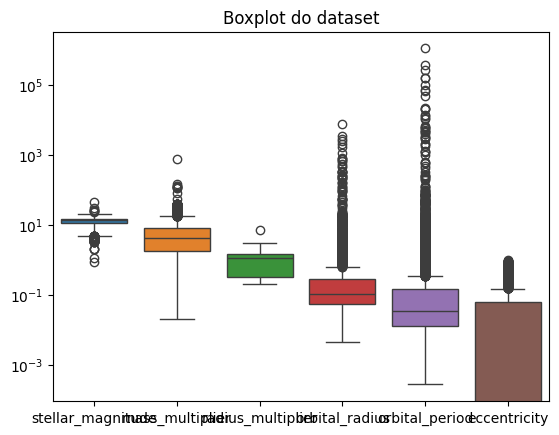

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df)
plt.title('Boxplot do dataset') 
plt.yscale("log")
plt.show()

Como foi possível perceber, existe um número considerável de outliers em quase todas as colunas do conjunto de dados. Vamos plotar individualmente cada uma das colunas para ver se 
conseguimos extrair alguma informação que possa vir a ser útil para contornar esse problema:

array([[<Axes: title={'center': 'stellar_magnitude'}>,
        <Axes: title={'center': 'mass_multiplier'}>],
       [<Axes: title={'center': 'radius_multiplier'}>,
        <Axes: title={'center': 'orbital_radius'}>],
       [<Axes: title={'center': 'orbital_period'}>,
        <Axes: title={'center': 'eccentricity'}>]], dtype=object)

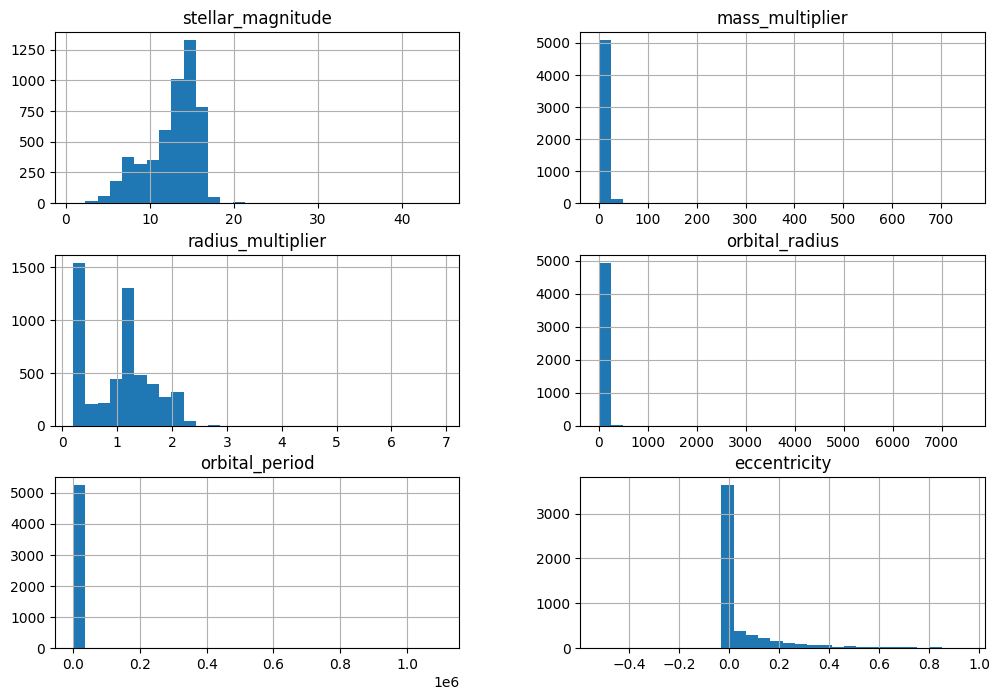

In [39]:
categorical_columns = df.select_dtypes(include=['object']).columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

df.hist(bins=30, figsize=(12,8))




